In [1]:
import struct
import numpy as np

In [2]:
def read_idx1(filename):
    with open(filename, 'rb') as f:
        magic, num_items = struct.unpack(">II", f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels

In [3]:
def read_idx3(filename):
    with open(filename, 'rb') as f:
        magic, num_images, rows, cols = struct.unpack(">IIII", f.read(16))
        images = np.frombuffer(
            f.read(), dtype=np.uint8
        ).reshape(num_images, rows, cols)
    return images

In [4]:
def filter_num(x, labels, images):
    num_images = []
    for i in range(0,60000):
        if (labels[i] == x):
            num_images.append(images[i])  

    return np.array(num_images)

In [5]:
def resize_images(images):
    new_images = []
    for i in range(0,len(images)):
        new_images.append(np.reshape(images[i],784))
    return np.array(new_images)/255

In [6]:
def mean_mle(samples):
    return sum(samples)/len(samples)

In [7]:
def cov_matrix_mle(samples,mean):
    var = []
    for i in range(0,len(samples)):
        y = np.reshape((samples[i]-mean),(784,1)) @ np.reshape((samples[i]-mean),(1,784))
        var.append(y)
    return np.array(sum(var))/len(samples)

In [8]:
def compute_params_qda(mean,variance,prior):
    quadratic_term = (-0.5)*(np.linalg.inv(variance + 0.0001 * np.eye(variance.shape[0])))
    linear_term = mean @ (np.linalg.inv(variance + 0.0001 * np.eye(variance.shape[0])))
    constant_term =  (-0.5) * (mean @ (np.linalg.inv(variance + 0.0001 * np.eye(variance.shape[0]))) @ mean + np.log(np.linalg.det(variance) if np.linalg.det(variance) > 0 else 1)) + np.log(prior)
    return (quadratic_term,linear_term,constant_term)

In [9]:
def compute_params_lda(mean,variance,prior):
    linear_term = mean @ (np.linalg.inv(variance + 0.0001 * np.eye(variance.shape[0])))
    constant_term =  (-0.5) * (mean @ (np.linalg.inv(variance + 0.0001 * np.eye(variance.shape[0]))) @ mean) + np.log(prior)
    return (linear_term,constant_term)

In [10]:
def linear_discriminant(point,params):
    return params[0] @ point + params[1]  

In [11]:
def quadratic_discriminant(point,params):
    return point @ params[0] @ point + params[1] @ point + params[2]

In [12]:
#read MNIST images and labels
labels = read_idx1(r"C:\Users\Mayank\Downloads\SML_A1_DATASET\train-labels.idx1-ubyte")
images = read_idx3(r"C:\Users\Mayank\Downloads\SML_A1_DATASET\train-images.idx3-ubyte")

#conversion to feature columns
images = resize_images(images)

train = {}
test = {}
mle = {}

for i in range(3):
    #filter for class 0,1,2 in corresponding iteration
    class_data = filter_num(i,labels,images)

    #random permutation of number
    np.random.seed(57)
    random_data = np.random.permutation(len(class_data))

    #apply this to data and select 0-99 & 100-199 for train and test, these are random since permutation was random
    train[i] = class_data[random_data[:100]]
    test[i] = class_data[random_data[100:200]]

    #compute mle estimates using train data
    mean = mean_mle(train[i])
    cov = cov_matrix_mle(train[i], mean)
    mle[i] = (mean,cov)

In [13]:
def compute_data_matrix(samples):
    return np.vstack([samples[0], samples[1], samples[2]]).T

def compute_mean(data_matrix):
    return data_matrix.sum(axis=1)/data_matrix.shape[1]

def compute_covariance(data_matrix):
    #X tranpose X / N - 1
    return (data_matrix @ data_matrix.T)/(data_matrix.shape[1] - 1)
    
def pca(samples, variance = 1, components = 0):
    data_matrix = compute_data_matrix(samples)
    mean = compute_mean(data_matrix)
    centered_data_mat = np.subtract(data_matrix, np.reshape(mean, (784,1)))
    covariance = compute_covariance(centered_data_mat)
    
    #eigenvalue problem
    eigenvalues, eigenvectors = np.linalg.eig(covariance)

    #covariance is positive semidefinite, so we must ignore complex and negative eigenvalues, which arise due to computational errors
    eigenvalues = np.real(eigenvalues)
    eigenvectors = np.real(eigenvectors)
    for i in range(eigenvalues.shape[0]):
        if eigenvalues[i] < 0:
            eigenvalues[i] = 0
            
    #sort eigenvalues and eigenvectors on non increasing order
    keys = eigenvalues
    sorted_keys = np.argsort(keys)[::-1]
    sorted_eigenvectors = eigenvectors[sorted_keys]
    sorted_eigenvalues = eigenvalues[sorted_keys]

    #if variance preservation threshold given, then take the first x eigenvectors which preserve the required variance
    if (variance < 1 and variance > 0):
        total = np.sum(sorted_eigenvalues)
        retain_indices = 0
        retain_var = sorted_eigenvalues[0]

        #loop till threshold is met
        for i in range(1, eigenvalues.shape[0]):
            retain_indices+=1
            retain_var += sorted_eigenvalues[retain_indices]
            if (retain_var/total >= variance):
                break
        
        return sorted_eigenvectors[:, :retain_indices]

    #if number of PCA components given, return largest component number of eigenvectors
    elif (components > 0 and components < sorted_eigenvectors.shape[0]):
        return sorted_eigenvectors[:, :components]

    #else return everything
    else:
        return sorted_eigenvectors

In [14]:
def between_class_scatter(class_means, global_mean):
    #this is size of each class (100) time class_mean - global_mean * (class_mean - global_mean)T over all classes
    var = []
    for i in range(3):
        var.append(100*( np.reshape(class_means[i] - global_mean, (784,1)) @ np.reshape(class_means[i] - global_mean, (1,784))))
    return np.array(sum(var))
                   
def within_class_scatter(class_cov):
    #this is just the biased covariance of each class multiplied with the number of samples in each class, which is 100
    return 100*(class_cov[0] + class_cov[1] + class_cov[2])
    
def fda(samples):
    class_means = {}
    class_cov = {}

    #compute mle mean and cov for each class
    for i in range(3):
        class_means[i] = mean_mle(samples[i])
        class_cov[i] = cov_matrix_mle(samples[i], class_means[i])

    #global mean
    global_mean = (class_means[0]+class_means[1]+class_means[2])/3

    Sb = between_class_scatter(class_means, global_mean)
    Sw = within_class_scatter(class_cov)

    #Need to solve Sb*w = lambda*Sw*w, so make Sw invertible if not and then solve Sw-1*Sb*w = lambda*w, which is the usual eigenvalue problem
    if (np.linalg.det(Sw) == 0):
        Sw += 0.001*np.eye(Sw.shape[0])

    #eigenvalue problem
    eigenvalues, eigenvectors = np.linalg.eig(np.linalg.inv(Sw) @ Sb)

    #covariance is positive semidefinite, so we must ignore complex and negative eigenvalues, which arise due to computational errors
    eigenvalues = np.real(eigenvalues)
    eigenvectors = np.real(eigenvectors)
    for i in range(eigenvalues.shape[0]):
        if eigenvalues[i] < 0:
            eigenvalues[i] = 0
            
    #sort eigenvalues and eigenvectors on non increasing order
    keys = eigenvalues
    sorted_keys = np.argsort(keys)[::-1]
    sorted_eigenvectors = eigenvectors[sorted_keys]
    sorted_eigenvalues = eigenvalues[sorted_keys]

    W = sorted_eigenvectors[:,:2]
    return W

In [15]:
def transform(project, samples):
    return project.T @ samples

In [16]:
def classify(test,mle,project,name,pca = False):
    cl = 0
    cq = 0
    params = {}
    for i in range(3):
        params[i] = {}
        if pca:
            #pca data is centered so mean is zero, covariance matrix is UT S U
            params[i]["qda"] = compute_params_qda(project.T @ (mle[i][0] - mle[i][0]), project.T @ mle[i][1] @ project, 1/3)
            params[i]["lda"] = compute_params_lda(project.T @ (mle[i][0] - mle[i][0]), project.T @ (mle[0][1] + mle[1][1] + mle[2][1])/3 @ project,1/3)
        else:
            params[i]["qda"] = compute_params_qda(project.T @ mle[i][0], project.T @ mle[i][1] @ project, 1/3)
            params[i]["lda"] = compute_params_lda(project.T @ mle[i][0], project.T @ (mle[0][1] + mle[1][1] + mle[2][1])/3 @ project,1/3)

    if pca:
        print("Reconstruction Demonstration\n")
        p1 = test[0][0]
        p2 = test[0][3]
        p3 = test[1][27]
        p4 = test[1][52]
        p5 = test[2][98]
        p6 = test[2][77]
        points = [p1,p2,p3,p4,p5,p6]
        error = 0
        for i in range(6):
            print(f"Point #{i}\n")
            print("point:",points[i])
            mean_removed = points[i] - (mle[0][0] + mle[1][0] + mle[2][0])/3
            print("mean removed point:",mean_removed)
            projected = project.T @ mean_removed
            print("pca projected point:", projected)
            reconstructed =  project @ projected + (mle[0][0] + mle[1][0] + mle[2][0])/3
            print("reconstructed point:", reconstructed)
            error += (points[i] - reconstructed) @ (points[i] - reconstructed)

        print("MSE:", error/6)

    num = 0
    for i in range(3):
        for j in test[i]:
            #linear discriminant
            linear = [0,0,0]
            quadratic = [0,0,0]
            if pca:
                point = j - (mle[0][0] + mle[1][0] + mle[2][0])/3 #center by mean
            else:
                point = j
                
            for k in range(3):
                linear[k] = linear_discriminant(project.T @ point,params[k]["lda"])
                quadratic[k] = quadratic_discriminant(project.T @ point,params[k]["qda"])

            l_pred = 0
            q_pred = 0
            for l in range(3):
                if (linear[l] == max(linear)):
                    l_pred = l
                if (quadratic[l] == max(quadratic)):
                    q_pred = l

            if (l_pred == i):
                cl+=1
            if (q_pred == i):
                cq+=1
            num+=1

            #print(f"Test #{num} Actual = {i}\n")
            #print(f"Linear Discriminant\nClass Zero:{linear[0]}\tOne:{linear[1]}\tTwo:{linear[2]}\nLDA Prediction = {l_pred}\n")
            #print(f"Quadratic Discriminant\nClass Zero:{quadratic[0]}\tOne:{quadratic[1]}\tTwo:{quadratic[2]}\nLDA Prediction = {q_pred}\n")

    print(f"\n{name}\nAccuracy\nLDA Accuracy = {cl/300}\nQDA Accuracy = {cq/300}")

In [17]:
w = fda(train)
u75 = pca(train, 0.75)
u90 = pca(train, 0.90)
u95 = pca(train, 0.95)
u2comp = pca(train, components = 2)

In [18]:
classify(test,mle,w,"FDA ON TEST DATA")


FDA ON TEST DATA
Accuracy
LDA Accuracy = 0.6
QDA Accuracy = 0.61


In [19]:
classify(train,mle,w,"FDA ON TRAIN DATA")


FDA ON TRAIN DATA
Accuracy
LDA Accuracy = 0.6666666666666666
QDA Accuracy = 0.68


In [20]:
classify(test,mle,u75,"PCA 75% VAR ON TEST",True)

Reconstruction Demonstration

Point #0

point: [0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.      

In [21]:
classify(train,mle,u75,"PCA 75% VAR ON TRAIN",True)

Reconstruction Demonstration

Point #0

point: [0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.      

In [22]:
classify(test,mle,u90,"PCA 90% VAR ON TEST",True)

Reconstruction Demonstration

Point #0

point: [0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.      

In [23]:
classify(train,mle,u90,"PCA 90% VAR ON TRAIN",True)

Reconstruction Demonstration

Point #0

point: [0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.      

In [24]:
classify(test,mle,u90,"PCA 95% VAR ON TEST",True)

Reconstruction Demonstration

Point #0

point: [0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.      

In [25]:
classify(train,mle,u95,"PCA 95% VAR ON TRAIN",True)

Reconstruction Demonstration

Point #0

point: [0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.      

In [26]:
classify(test,mle,u2comp,"PCA 2 COMPONENTS ON TEST",True)

Reconstruction Demonstration

Point #0

point: [0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.      

In [27]:
classify(train,mle,u2comp,"PCA 2 COMPONENTS ON TRAIN",True)

Reconstruction Demonstration

Point #0

point: [0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.      

In [28]:
import matplotlib.pyplot as plt

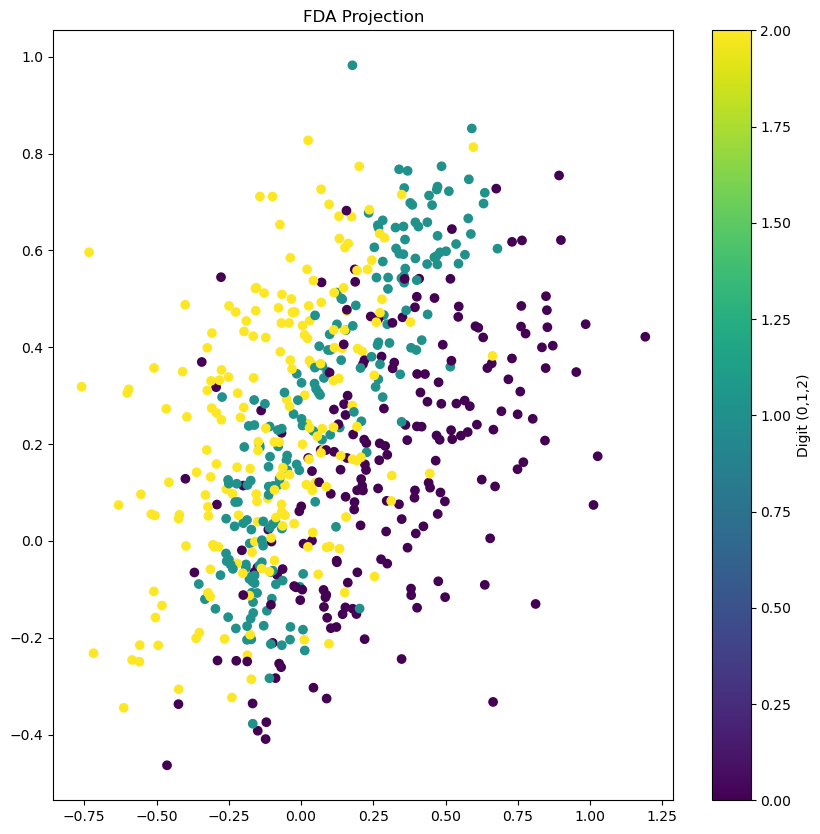

In [29]:
X_train = np.vstack([train[0], train[1], train[2]]) @ w
X_test  = np.vstack([test[0],  test[1],  test[2]]) @ w

y_train = np.array(
    [0]*len(train[0]) +
    [1]*len(train[1]) +
    [2]*len(train[2])
)

y_test = np.array(
    [0]*len(test[0]) +
    [1]*len(test[1]) +
    [2]*len(test[2])
)

X_all = np.vstack([X_train, X_test])
y_all = np.concatenate([y_train, y_test])

plt.figure(figsize=(10, 10))

plt.scatter(
    X_all[:,0], X_all[:,1],
    c=y_all
)

plt.colorbar(label="Digit (0,1,2)")
plt.title("FDA Projection")
plt.show()

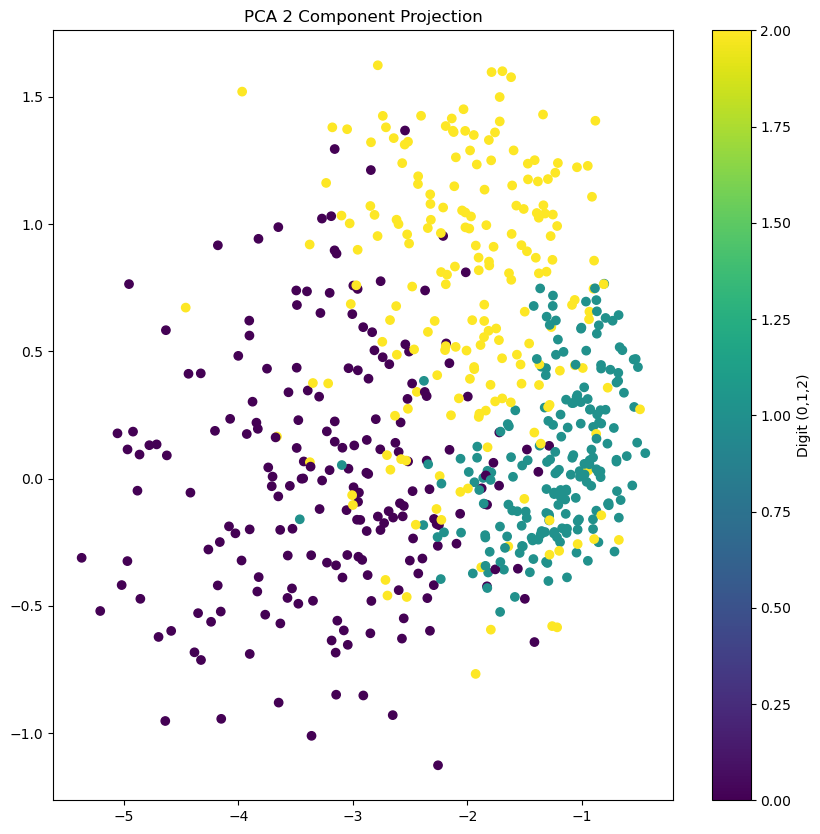

In [30]:
X_train = np.vstack([train[0], train[1], train[2]]) @ u2comp
X_test  = np.vstack([test[0],  test[1],  test[2]]) @ u2comp

y_train = np.array(
    [0]*len(train[0]) +
    [1]*len(train[1]) +
    [2]*len(train[2])
)

y_test = np.array(
    [0]*len(test[0]) +
    [1]*len(test[1]) +
    [2]*len(test[2])
)

X_all = np.vstack([X_train, X_test])
y_all = np.concatenate([y_train, y_test])

plt.figure(figsize=(10, 10))

plt.scatter(
    X_all[:,0], X_all[:,1],
    c=y_all
)

plt.colorbar(label="Digit (0,1,2)")
plt.title("PCA 2 Component Projection")
plt.show()